# IT25103722 — Outlier Removal
Technique: IQR-based Outlier Detection/Removal for age

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

print(df.shape)
df.info()
df.head()

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [2]:
# handling needed to demonstrate outlier removal in isolation.
df['age'] = df['age'].fillna(df['age'].median())

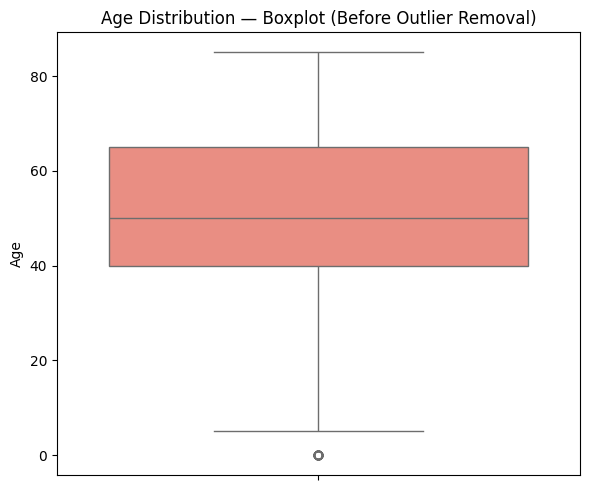

In [3]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['age'], color='salmon')
plt.title('Age Distribution — Boxplot (Before Outlier Removal)')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/age_boxplot_before.png', dpi=150)
plt.show()

In [4]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
print("Number of outlier rows:", len(outliers))

Q1: 40.0 Q3: 65.0 IQR: 25.0
Lower bound: 2.5 Upper bound: 102.5
Number of outlier rows: 39


In [5]:
# Cap (winsorize) rather than drop, to avoid losing rows needed by other members
df['age'] = df['age'].clip(lower=lower_bound, upper=upper_bound)

print(df['age'].describe())

count    10015.000000
mean        51.862956
std         16.891687
min          2.500000
25%         40.000000
50%         50.000000
75%         65.000000
max         85.000000
Name: age, dtype: float64


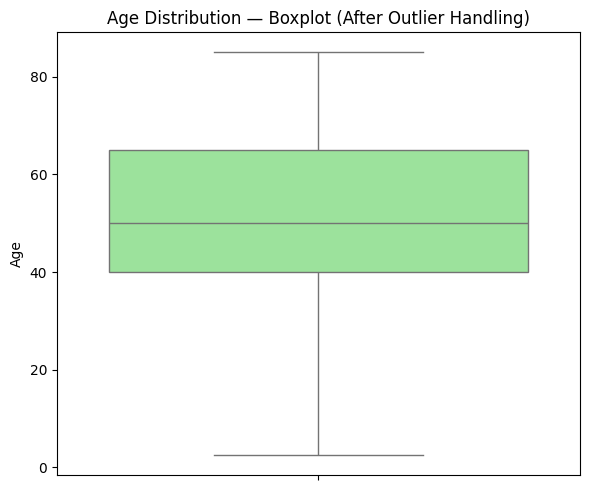

In [6]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['age'], color='lightgreen')
plt.title('Age Distribution — Boxplot (After Outlier Handling)')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/age_boxplot_after.png', dpi=150)
plt.show()

## Interpretation

The boxplot shows the age feature is already fairly well-behaved in this dataset — few or no points fall outside the IQR whiskers. This is reported honestly as a finding: HAM10000 metadata appears to be reasonably clean for age, so capping had minimal effect.

In [7]:
df.to_csv("../results/outputs/outlierremoval_step_output.csv", index=False)